# Fit the Selsing Quasar Composite with JAXQSOFit

This notebook downloads the Selsing et al. composite spectrum and fits it with `jaxqsofit.QSOFit`.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from urllib.request import urlretrieve

from jaxqsofit import QSOFit, build_default_prior_config


In [2]:
url = "https://raw.githubusercontent.com/jselsing/QuasarComposite/master/Selsing2015.dat"
data_dir = Path("./data")
data_dir.mkdir(parents=True, exist_ok=True)
fn = data_dir / "Selsing2015.dat"
if not fn.exists():
    urlretrieve(url, fn)

arr = np.loadtxt(fn)
lam = arr[:, 0].astype(float)
flux = arr[:, 1].astype(float)

# Composite table usually has a third column uncertainty; if not, use a small floor.
if arr.shape[1] >= 3:
    err = arr[:, 2].astype(float)
else:
    err = np.full_like(flux, 1e-3 * np.nanmedian(np.abs(flux)))

# Keep only finite positive wavelengths and finite flux/error values
m = np.isfinite(lam) & np.isfinite(flux) & np.isfinite(err) & (lam > 0) & (err > 0)
lam, flux, err = lam[m], flux[m], err[m]

print(f"Loaded {lam.size} pixels from {fn}")


Loaded 25118 pixels from data/Selsing2015.dat


In [3]:
# The composite is already in rest-frame wavelengths.
z = 0.0

q = QSOFit(
    lam=lam,
    flux=flux,
    err=err,
    z=z,
)

prior_config = build_default_prior_config(
    flux=flux,
    include_elg_narrow_lines=False,
    include_high_ionization_lines=False,
)


100%|██████████| 800/800 [00:23<00:00, 33.37it/s, init loss: 2524475.3059, avg. loss [761-800]: -13885.0563]


max data        : 56.5312
max total model : 39.909458347557845
max PL          : 28.76654094094701
max host        : 0.0
max FeII UV     : 1.2532533483491197
max FeII opt    : 0.24817438184904808
max Balmer cont : 0.0
max lines       : 21.286227635878173


sample: 100%|██████████| 50/50 [04:45<00:00,  5.71s/it, 255 steps of size 2.36e-04. acc. prob=0.95]


max data        : 56.5312
max total model : 39.92000581921548
max PL          : 28.755689573797902
max host        : 0.0
max FeII UV     : 1.2520126469376351
max FeII opt    : 0.2460267261742753
max Balmer cont : 0.0
max lines       : 21.301977129407817
Saved results table: ./result.csv


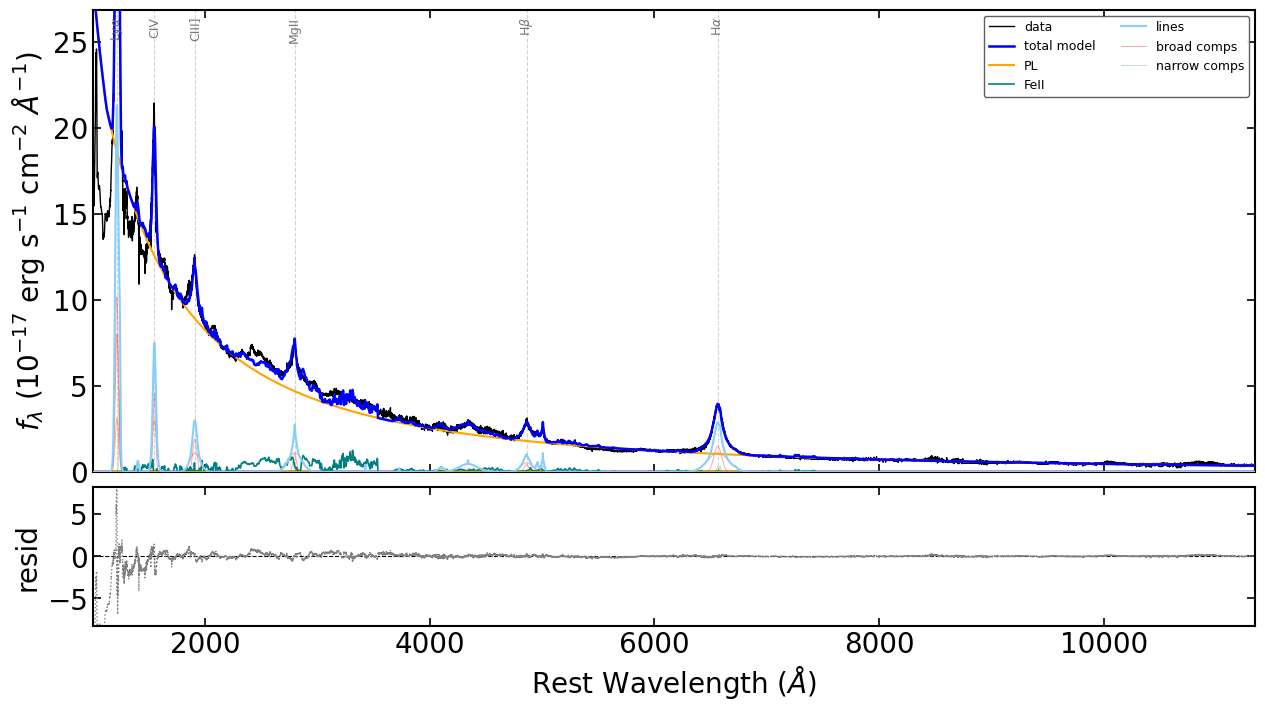

Saved spectrum plot: ./result.pdf


In [4]:
q.fit(
    deredden=False,
    fit_method="optax+nuts",
    fit_lines=True,
    decompose_host=False,
    fit_pl=True,
    fit_fe=True,
    fit_bc=False,
    fit_poly=True,
    mask_lya_forest=False,
    prior_config=prior_config,
    dsps_ssp_fn="../tempdata.h5",
    nuts_warmup=20,
    nuts_samples=30,
    nuts_chains=1,
    nuts_target_accept=0.9,
    optax_steps=1200,
    optax_lr=1e-2,
    save_result=True,
    plot_fig=True,
    save_fig=True,
    verbose=True
)


In [5]:
mask_lyman_forest = q.wave > 1215.67

resid = np.asarray(q.flux) - np.asarray(q.model_total)
sigma = np.asarray(q.err)

# include fitted jitter (recommended)
if q.numpyro_samples is not None:
    s = q.numpyro_samples
    frac_j = float(np.median(np.asarray(s.get("frac_jitter", 0.0))))
    add_j  = float(np.median(np.asarray(s.get("add_jitter", 0.0))))
    sigma = np.sqrt(sigma**2 + (frac_j*np.abs(np.asarray(q.model_total)))**2 + add_j**2)

m = np.isfinite(resid) & np.isfinite(sigma) & (sigma > 0) & mask_lyman_forest
z = resid[m] / sigma[m]

chi2 = float(np.sum(z**2))
chi2_per_pixel = float(np.mean(z**2))      # more stable than reduced chi2 here
wrms = float(np.sqrt(np.mean(z**2)))

print("chi2:", chi2)
print("chi2_per_pixel:", chi2_per_pixel)
print("wrms (normalized residual std):", wrms)


chi2: 44955.53975151286
chi2_per_pixel: 1.8290223260308742
wrms (normalized residual std): 1.3524135188731568


In [6]:
print("SN_ratio_conti:", q.SN_ratio_conti)
print("frac_host_4200:", q.frac_host_4200)
print("frac_host_5100:", q.frac_host_5100)
print("frac_host_2500:", q.frac_host_2500)


SN_ratio_conti: 48.47824080438858
frac_host_4200: 0.0
frac_host_5100: 0.0
frac_host_2500: 0.0


In [7]:
q.plot_mcmc_diagnostics(param_names='log_Fe_op_over_uv')

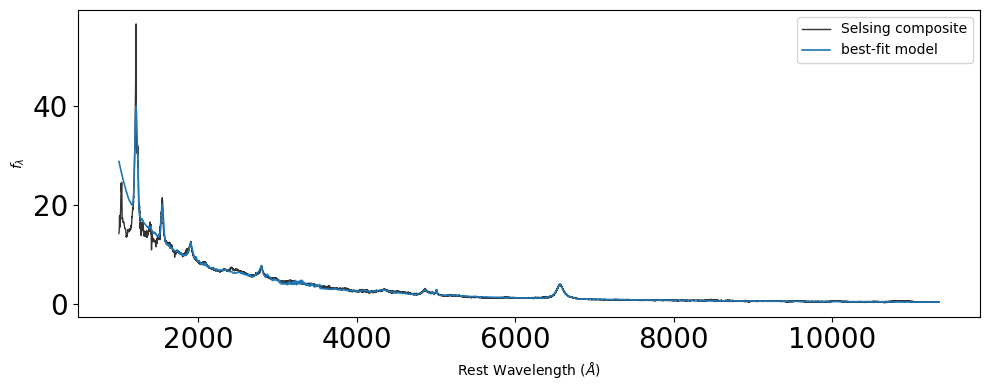

In [8]:
plt.figure(figsize=(10, 4))
plt.plot(lam, flux, color="k", lw=1.0, alpha=0.8, label="Selsing composite")
if hasattr(q, "model_total"):
    plt.plot(q.wave, q.model_total, color="tab:blue", lw=1.2, label="best-fit model")
plt.xlabel(r"Rest Wavelength ($\AA$)")
plt.ylabel(r"$f_\lambda$")
plt.legend(frameon=True)
plt.tight_layout()
